In [1]:
print("first lesson")

first lesson


In [5]:
#let's learn about a function because machine learning about fitting a function to the data

def f(x):
    #4x^2 -4x + 5
    return 4*x**2 -4*x + 5 
    

In [6]:
#let's feed some data to above function
f(4)

53

In [7]:
f(10)

365

In [28]:
# Now I want to visualize this function
# I will give value from 0,10

xaxis = [i for i in range(100)]

In [20]:
xaxis

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [29]:
yaxis = [] 
for i in xaxis :yaxis.append(f(i))

In [ ]:
ys =map(f,xaxis)

In [25]:
yaxis

[5, 5, 13, 29, 53, 85, 125, 173, 229, 293]

In [26]:
import matplotlib.pyplot as plt

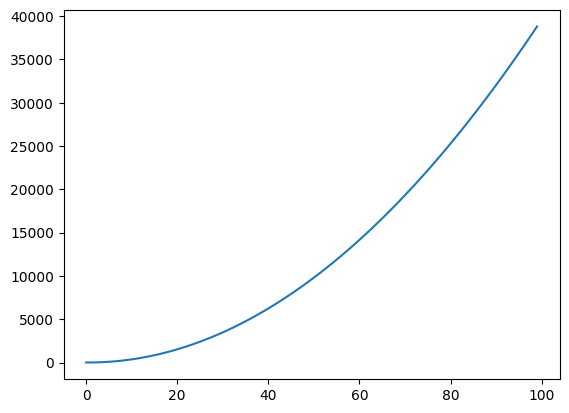

In [30]:
plt.plot(xaxis,yaxis)

In [43]:
import numpy as np

In [44]:
xs= np.arange(-5,5,0.25)

In [196]:
ys = f(xs)

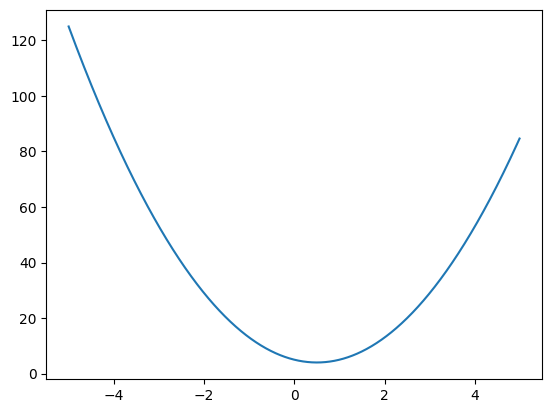

In [197]:
plt.plot(xs,ys)

In [82]:
ys =map(f,xaxis)

In [397]:

xs = np.arange(-5,5,0.01)
ys = f(xs)

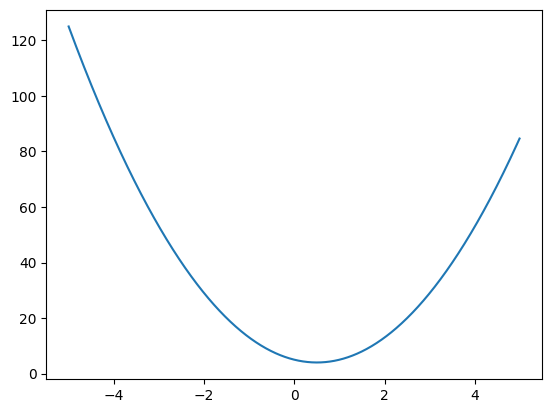

In [262]:
plt.plot(xs,ys)

In [52]:
# Now we will discuss about the derivative of a function
# By definition the derivative show the sensitivity of change of function's output with respect to input

#h--> 0
#(f(x+h) + f(x))/h

In [200]:
# now applying the derivative to the function

def derivativefx(x):
    h=0.00000001
    return (f(x+h)-f(x))/h

In [201]:
derivativefx(25)

196.00001905928366

In [56]:
f(25)

2405

In [59]:
derivativefx(0)

-3.99999960265518

In [60]:
derivativefx(-5)

-43.99999980364555

In [61]:
derivativefx(75)

595.9999543847516

In [62]:
f(75)

22205

In [63]:
f(75.00001)

22205.005960000402

In [68]:
#now from the above example we can see if derivative -negative then if you increase the value 
#outwill reduce and when possitive when you increase the input output also increase

In [70]:
len(ys)

20000

In [77]:
#now let's do a work of prediction
# our actual function was 4x^2 -4x+5
# and it gave our output ys
# now say we don't know the function we gave an output of ys and input xs now want to fit a function ax^2 + bx + c, we have to find a,b,c

In [325]:
#OK NOW DERIVE IT
# We can initialize it will small values
a=1.0
b=1.0
c=1.0

In [326]:
def newfun(x,a=1.0,b=1.0,c=1.0):
    return a*x**2 + b*x + c


In [327]:
# now we have to find the loss, it's a caculation how much variation is there with actual
act = ys

In [349]:
pred= newfun(xs)

In [348]:
def loss(pred):
    return sum((pred -act)**2)/len(act)

In [363]:
pred= newfun(xs,a = 3.044805285095208, b= 0.7896911736461334, c=1.1451252273909631)
actual_loss = loss(pred)
actual_loss

382.7847976916112

In [364]:
a,b,c = 3.044805285095208, 0.7896911736461334, 1.1451252273909631
# a,b,c = 1,1,1
old_a = a
old_b = b
old_c = c

h =0.0000000001
#let's day d is our loss
a+=h
pred= newfun(xs,a=a,b=old_b,c=old_c)
der_a = (loss(pred) - actual_loss)/h

b+=h
pred= newfun(xs,a=old_a,b=b,c=old_c)
der_b = (loss(pred) - actual_loss)/h

c+=h
pred= newfun(xs,a=old_a,b=old_b,c=c)
der_c = (loss(pred) - actual_loss)/h

In [365]:
der_a,der_b,der_c

(-304.2555363208521, 80.10999863472534, -23.679831429035403)

In [366]:
(-2/len(act)) * sum(xs*xs*(act - pred))

-304.24573488114265

In [367]:
(-2/len(act)) * sum(xs*(act - pred))

80.10569331026187

In [368]:
(-2/len(act)) * sum((act - pred))

-23.677590211658597

In [292]:
der_a*0.0025

-2.0447600945772137

In [210]:
loss()

1553291.6491790467

In [211]:
der_a*0.0025

-2044.813008978963

In [337]:
#now we have to reduce the loss,to reduce the loss we want to identify if a change in input where loss it moving we can't change x i.e that's input
# only we can change is a, b, c now find derivative of each input with respect to loss
old_a = a
old_b = b
old_c = c

h =0.0000001
#let's day d is our loss
a+=h
pred= newfun(xs,a=a,b=old_b,c=old_c)
der_a = (loss(pred) - actual_loss)/h

b+=h
pred= newfun(xs,a=old_a,b=b,c=old_c)
der_b = (loss(pred) - actual_loss)/h

b+=h
pred= newfun(xs,a=old_a,b=old_b,c=c)
der_c = (loss(pred) - actual_loss)/h

In [ ]:
der

In [338]:
der_a,der_b,der_c


(-22973621.99012014, -22972720.670577474, -22972804.84170415)

In [416]:
def update_parameters(a,b,c,actual_loss):
    old_a = a
    old_b = b
    old_c = c

    h =0.00000001
    #let's day d is our loss
    a+=h
    pred= newfun(xs,a=a,b=old_b,c=old_c)
    der_a = (loss(pred) - actual_loss)/h

    b+=h
    pred= newfun(xs,a=old_a,b=b,c=old_c)
    der_b = (loss(pred) - actual_loss)/h

    c+=h
    pred= newfun(xs,a=old_a,b=old_b,c=c)
    der_c = (loss(pred) - actual_loss)/h
   
    a = old_a-.0025*der_a
    b = old_b-.0025*der_b
    c = old_c-.0025*der_c
   
    print(der_a,der_b,der_c,"values {},{},{}".format(a,b,c),actual_loss)
    return a, b, c

In [425]:
a,b,c = 1,1,1
for i in range(500):
    pred= newfun(xs,a , b, c)
    actual_loss = loss(pred)


    a,b,c = update_parameters(a,b,c,actual_loss)
  

-817.9221140380832 84.12353054154664 -58.05009095638525 values 3.044805285095208,0.7896911736461334,1.1451252273909631 1553.291649996972
-304.24567398767977 80.1057296939689 -23.67752927057154 values 3.8054194700644075,0.5894268494112112,1.204319050567392 382.7847976916112
-113.05430120955862 76.57724268028687 -10.880262379941996 values 4.088055223088304,0.39798374271049397,1.231519706517247 207.3708357547585
-41.893662228176254 73.31557014822465 -6.11330222000106 values 4.192789378658745,0.21469481733993234,1.2468029620672496 170.89483303400118
-15.409418097078742 70.23440105058398 -4.335362291385536 values 4.2313129239014415,0.039108814713472384,1.2576413677957134 154.6586356335173
-5.553957294068823 67.29817414452555 -3.669907755465829 values 4.245197817136614,-0.12913662064784148,1.266816137184378 142.13706263768586
-1.8877159391195164 64.49054694712686 -3.418429628254671 values 4.249917106984412,-0.29036298801565863,1.2753622112550147 130.96645383918818
-0.5251422408036888 61.8021

In [426]:
a,b,c


(4.083659778801984, -3.99946708185095, 3.749547420050069)

In [427]:
y_x = newfun(xs,a=a,b=b,c=c)

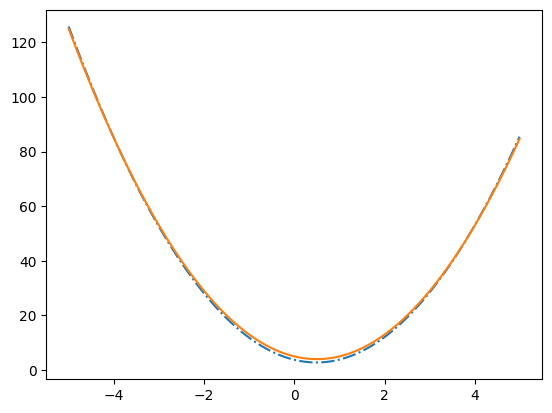

In [428]:
plt.plot(xs,y_x,"-.",label = 'pre')
plt.plot(xs,ys,label="actual")

In [228]:
b

2044814.008978963

In [229]:
c

2044814.008978963

In [257]:
xs

array([-5.0000000e+00, -4.9900000e+00, -4.9800000e+00, -4.9700000e+00,
       -4.9600000e+00, -4.9500000e+00, -4.9400000e+00, -4.9300000e+00,
       -4.9200000e+00, -4.9100000e+00, -4.9000000e+00, -4.8900000e+00,
       -4.8800000e+00, -4.8700000e+00, -4.8600000e+00, -4.8500000e+00,
       -4.8400000e+00, -4.8300000e+00, -4.8200000e+00, -4.8100000e+00,
       -4.8000000e+00, -4.7900000e+00, -4.7800000e+00, -4.7700000e+00,
       -4.7600000e+00, -4.7500000e+00, -4.7400000e+00, -4.7300000e+00,
       -4.7200000e+00, -4.7100000e+00, -4.7000000e+00, -4.6900000e+00,
       -4.6800000e+00, -4.6700000e+00, -4.6600000e+00, -4.6500000e+00,
       -4.6400000e+00, -4.6300000e+00, -4.6200000e+00, -4.6100000e+00,
       -4.6000000e+00, -4.5900000e+00, -4.5800000e+00, -4.5700000e+00,
       -4.5600000e+00, -4.5500000e+00, -4.5400000e+00, -4.5300000e+00,
       -4.5200000e+00, -4.5100000e+00, -4.5000000e+00, -4.4900000e+00,
       -4.4800000e+00, -4.4700000e+00, -4.4600000e+00, -4.4500000e+00,
      

In [258]:
ys

array([125.    , 124.5604, 124.1216, 123.6836, 123.2464, 122.81  ,
       122.3744, 121.9396, 121.5056, 121.0724, 120.64  , 120.2084,
       119.7776, 119.3476, 118.9184, 118.49  , 118.0624, 117.6356,
       117.2096, 116.7844, 116.36  , 115.9364, 115.5136, 115.0916,
       114.6704, 114.25  , 113.8304, 113.4116, 112.9936, 112.5764,
       112.16  , 111.7444, 111.3296, 110.9156, 110.5024, 110.09  ,
       109.6784, 109.2676, 108.8576, 108.4484, 108.04  , 107.6324,
       107.2256, 106.8196, 106.4144, 106.01  , 105.6064, 105.2036,
       104.8016, 104.4004, 104.    , 103.6004, 103.2016, 102.8036,
       102.4064, 102.01  , 101.6144, 101.2196, 100.8256, 100.4324,
       100.04  ,  99.6484,  99.2576,  98.8676,  98.4784,  98.09  ,
        97.7024,  97.3156,  96.9296,  96.5444,  96.16  ,  95.7764,
        95.3936,  95.0116,  94.6304,  94.25  ,  93.8704,  93.4916,
        93.1136,  92.7364,  92.36  ,  91.9844,  91.6096,  91.2356,
        90.8624,  90.49  ,  90.1184,  89.7476,  89.3776,  89.0